In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'GSE227666' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/GSE227666.ipynb
/content/drive/MyDrive/GSE227666/GSE227666_neopembrov_counts.txt
/content/drive/MyDrive/GSE227666/GSE227666_family.soft.gz


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/GSE227666/GSE227666_neopembrov_counts.txt',
                 sep='\t',
                 index_col=0)

print(df.shape)
print(df.head())
print(df.iloc[:5, :5])
df_rounded = df.round().astype(int)
print(df_rounded.head())

(25604, 109)
          R200622    R200630    R200634    R200635    R200636    R200637  \
symbol                                                                     
A1BG      182.332    254.086    150.058    220.837    160.027    245.564   
A1CF        4.029      3.000      0.000      1.001      0.000      1.870   
A2M     14121.445  11783.576  25755.820  33707.116  47381.688  22735.287   
A2ML1     146.579     75.223     90.510     29.731   1076.828     19.609   
A2MP1       0.000      0.000      0.000      0.000      0.000      0.000   

          R200638    R200639    R200640    R200641  ...    R210188    R210189  \
symbol                                              ...                         
A1BG      283.616     86.237    142.480    216.007  ...     46.222     60.601   
A1CF        0.000      0.000      0.000      1.000  ...      1.000      0.000   
A2M     47605.953  42074.257  31035.995  31080.524  ...  30392.782  49225.732   
A2ML1    1005.691     36.303    211.979    116.65

In [4]:
df_rounded.to_csv('/content/drive/MyDrive/GSE227666/counts_clean.csv')

In [5]:
!pip install GEOparse

import GEOparse

gse = GEOparse.get_GEO(geo="GSE227666", destdir="/content/drive/MyDrive/GSE227666/")

metadata = []
for gsm_name, gsm in gse.gsms.items():
    metadata.append({
        'sample': gsm_name,
        'title': gsm.metadata['title'][0],
        'treatment': gsm.metadata['characteristics_ch1'][2]
    })

import pandas as pd
meta_df = pd.DataFrame(metadata)
print(meta_df.head(10))
print(meta_df['treatment'].value_counts())

22-May-2026 06:14:16 DEBUG utils - Directory /content/drive/MyDrive/GSE227666/ already exists. Skipping.
DEBUG:GEOparse:Directory /content/drive/MyDrive/GSE227666/ already exists. Skipping.
22-May-2026 06:14:16 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
22-May-2026 06:14:16 INFO GEOparse - Parsing /content/drive/MyDrive/GSE227666/GSE227666_family.soft.gz: 
INFO:GEOparse:Parsing /content/drive/MyDrive/GSE227666/GSE227666_family.soft.gz: 
22-May-2026 06:14:16 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
22-May-2026 06:14:16 DEBUG GEOparse - SERIES: GSE227666
DEBUG:GEOparse:SERIES: GSE227666
22-May-2026 06:14:16 DEBUG GEOparse - PLATFORM: GPL24676
DEBUG:GEOparse:PLATFORM: GPL24676
22-May-2026 06:14:16 DEBUG GEOparse - SAMPLE: GSM7104852
DEBUG:GEOparse:SAMPLE: GSM7104852
22-May-2026 06:14:16 DEBUG GEOparse - SAMPLE: GSM7104853
DEBUG:GEOparse:SAMPLE: GSM7104853
22-May-2026 06:14:16 DEBUG GEOparse -

       sample                                  title               treatment
0  GSM7104852  Ovarian cancer, NACT+P, Pre (R200622)  treatment: NACT+P, Pre
1  GSM7104853  Ovarian cancer, NACT+P, Pre (R200630)  treatment: NACT+P, Pre
2  GSM7104854    Ovarian cancer, NACT, Pre (R200634)    treatment: NACT, Pre
3  GSM7104855  Ovarian cancer, NACT+P, Pre (R200635)  treatment: NACT+P, Pre
4  GSM7104856  Ovarian cancer, NACT+P, Pre (R200636)  treatment: NACT+P, Pre
5  GSM7104857  Ovarian cancer, NACT+P, Pre (R200637)  treatment: NACT+P, Pre
6  GSM7104858  Ovarian cancer, NACT+P, Pre (R200638)  treatment: NACT+P, Pre
7  GSM7104859  Ovarian cancer, NACT+P, Pre (R200639)  treatment: NACT+P, Pre
8  GSM7104860    Ovarian cancer, NACT, Pre (R200640)    treatment: NACT, Pre
9  GSM7104861  Ovarian cancer, NACT+P, Pre (R200641)  treatment: NACT+P, Pre
treatment
treatment: NACT+P, Pre     32
treatment: NACT+P, Post    32
treatment: NACT, Post      24
treatment: NACT, Pre       21
Name: count, dtype: int

In [6]:
# Clean the treatment column
meta_df['treatment'] = meta_df['treatment'].str.replace('treatment: ', '')

# Extract the sample ID from the title (the R###### code)
meta_df['sample_id'] = meta_df['title'].str.extract(r'\((R\d+)\)')

print(meta_df.head())
print(meta_df['treatment'].value_counts())

       sample                                  title    treatment sample_id
0  GSM7104852  Ovarian cancer, NACT+P, Pre (R200622)  NACT+P, Pre   R200622
1  GSM7104853  Ovarian cancer, NACT+P, Pre (R200630)  NACT+P, Pre   R200630
2  GSM7104854    Ovarian cancer, NACT, Pre (R200634)    NACT, Pre   R200634
3  GSM7104855  Ovarian cancer, NACT+P, Pre (R200635)  NACT+P, Pre   R200635
4  GSM7104856  Ovarian cancer, NACT+P, Pre (R200636)  NACT+P, Pre   R200636
treatment
NACT+P, Pre     32
NACT+P, Post    32
NACT, Post      24
NACT, Pre       21
Name: count, dtype: int64


In [7]:
# Check overlap
count_samples = set(df_rounded.columns)
meta_samples = set(meta_df['sample_id'])

print(f"Samples in counts: {len(count_samples)}")
print(f"Samples in metadata: {len(meta_samples)}")
print(f"Matching: {len(count_samples & meta_samples)}")
print(f"In counts but not metadata: {count_samples - meta_samples}")

Samples in counts: 109
Samples in metadata: 109
Matching: 109
In counts but not metadata: set()


In [8]:
meta_df.to_csv('/content/drive/MyDrive/GSE227666/metadata_clean.csv', index=False)

In [9]:
import pandas as pd
import numpy as np

# Reload your saved files
df_rounded = pd.read_csv('/content/drive/MyDrive/GSE227666/counts_clean.csv',
                          index_col=0)
meta_df = pd.read_csv('/content/drive/MyDrive/GSE227666/metadata_clean.csv')

# Filter lowly expressed genes
min_samples = int(0.2 * df_rounded.shape[1])
keep = (df_rounded >= 10).sum(axis=1) >= min_samples

df_filtered = df_rounded[keep]
print(f"Genes before filtering: {df_rounded.shape[0]}")
print(f"Genes after filtering: {df_filtered.shape[0]}")

Genes before filtering: 25604
Genes after filtering: 19116


In [10]:
df_filtered.to_csv('/content/drive/MyDrive/GSE227666/counts_filtered.csv')

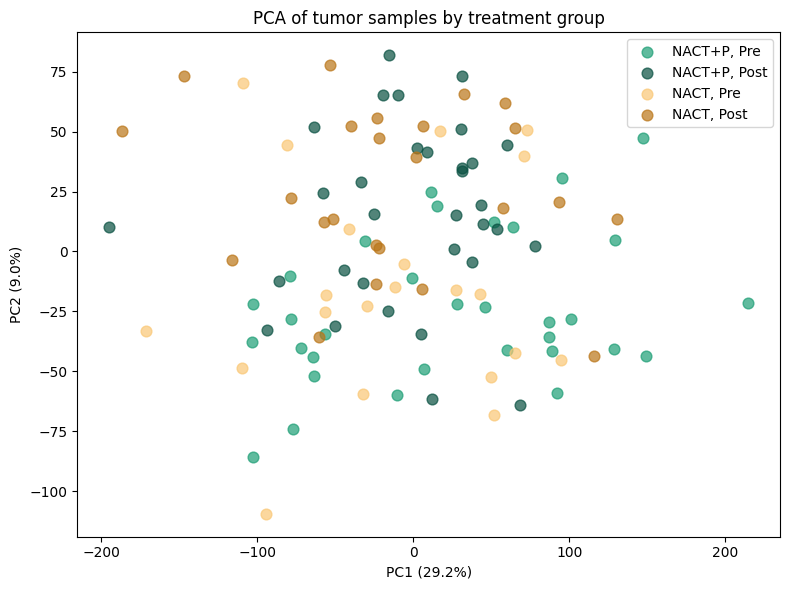

PC1 explains: 29.2%
PC2 explains: 9.0%


In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Log normalize first (standard before PCA)
df_log = np.log2(df_filtered + 1)

# Transpose so samples are rows, genes are columns
df_T = df_log.T

# Scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_T)

# Run PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(df_scaled)

# Build plot dataframe
pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'sample_id': df_filtered.columns
})

# Merge with metadata
pca_df = pca_df.merge(meta_df, on='sample_id')

# Plot colored by treatment group
fig, ax = plt.subplots(figsize=(8, 6))
colors = {
    'NACT+P, Pre': '#1D9E75',
    'NACT+P, Post': '#085041',
    'NACT, Pre': '#FAC775',
    'NACT, Post': '#BA7517'
}

for group, color in colors.items():
    mask = pca_df['treatment'] == group
    ax.scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
               label=group, color=color, alpha=0.7, s=60)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of tumor samples by treatment group')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GSE227666/PCA_by_treatment.png', dpi=150)
plt.show()

print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")

In [12]:
!pip install pydeseq2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 3.9 MB/s eta 0:00:00


In [13]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Subset to Post samples only
post_samples = meta_df[meta_df['treatment'].isin(['NACT+P, Post', 'NACT, Post'])]

# Align count matrix to these samples
counts_post = df_filtered[post_samples['sample_id']]

# Transpose for PyDESeq2 (needs samples as rows)
counts_post_T = counts_post.T

# Make sure metadata rows match count matrix rows
post_samples = post_samples.set_index('sample_id')
post_samples = post_samples.loc[counts_post_T.index]

# Create simplified group label
post_samples['group'] = post_samples['treatment'].map({
    'NACT+P, Post': 'NACTP',
    'NACT, Post': 'NACT'
})

print(post_samples['group'].value_counts())
print(f"Count matrix shape: {counts_post_T.shape}")

group
NACTP    32
NACT     24
Name: count, dtype: int64
Count matrix shape: (56, 19116)


In [14]:
# Build DESeq2 dataset
dds = DeseqDataSet(
    counts=counts_post_T,
    metadata=post_samples[['group']],
    design_factors='group'
)

# Run DESeq2
dds.deseq2()

# Extract results (NACTP vs NACT)
stat_res = DeseqStats(dds, contrast=['group', 'NACTP', 'NACT'])
stat_res.summary()

# Get results table
results = stat_res.results_df
print(results.shape)
print(results.head())

/tmp/ipykernel_521/2555549460.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.22 seconds.

Fitting dispersions...
... done in 46.67 seconds.

Fitting dispersion trend curve...
... done in 0.52 seconds.

Fitting MAP dispersions...
... done in 43.91 seconds.

Fitting LFCs...
... done in 17.90 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 860 outlier genes.

Fitting dispersions...
... done in 1.39 seconds.

Fitting MAP dispersions...
... done in 1.51 seconds.

Fitting LFCs...
... done in 1.40 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: group NACTP vs NACT
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
symbol                                                                       
A1BG       158.334684        0.145411  0.135540  1.072827  0.283349  0.908528
A2M      59075.882318       -0.474286  0.213615 -2.220285  0.026399  0.683810
A2ML1      249.783135        1.105462  0.444516  2.486887  0.012887  0.563709
A3GALT2      8.616786        0.150445  0.445290  0.337859  0.735469  0.984062
A4GALT     648.203710       -0.537983  0.272854 -1.971687  0.048645  0.747416
...               ...             ...       ...       ...       ...       ...
ZYG11A     224.259252        0.301871  0.356928  0.845746  0.397694  0.929628
ZYG11B    2696.820334       -0.008578  0.089935 -0.095375  0.924017  0.997079
ZYX       7214.814126        0.128268  0.151755  0.845233  0.397981  0.929628
ZZEF1    11235.254383       -0.041403  0.116757 -0.354603  0.722887  0.983020
ZZZ3  

... done in 6.36 seconds.



In [15]:
# Filter for significant genes
sig = results[
    (results['padj'] < 0.05) &
    (abs(results['log2FoldChange']) > 1)
].dropna()

print(f"Total genes tested: {results.shape[0]}")
print(f"Significant DE genes: {sig.shape[0]}")
print(f"\nUpregulated in NACT+P: {(sig['log2FoldChange'] > 0).sum()}")
print(f"Downregulated in NACT+P: {(sig['log2FoldChange'] < 0).sum()}")
print(f"\nTop 10 most significant genes:")
print(sig.sort_values('padj').head(10)[['log2FoldChange', 'padj']])

Total genes tested: 19116
Significant DE genes: 10

Upregulated in NACT+P: 4
Downregulated in NACT+P: 6

Top 10 most significant genes:
             log2FoldChange      padj
symbol                               
ATP13A4            2.690547  0.001215
IGHV1OR15-2       -3.786858  0.001215
RPL10P9           -4.568751  0.003561
HP                -2.776458  0.011981
MUC12              2.614283  0.011981
CXCL1             -2.010102  0.032410
PRB1               4.252169  0.038389
PKD1L3            -1.076972  0.041267
CA1               -1.990770  0.049168
CLVS1              1.602317  0.049168


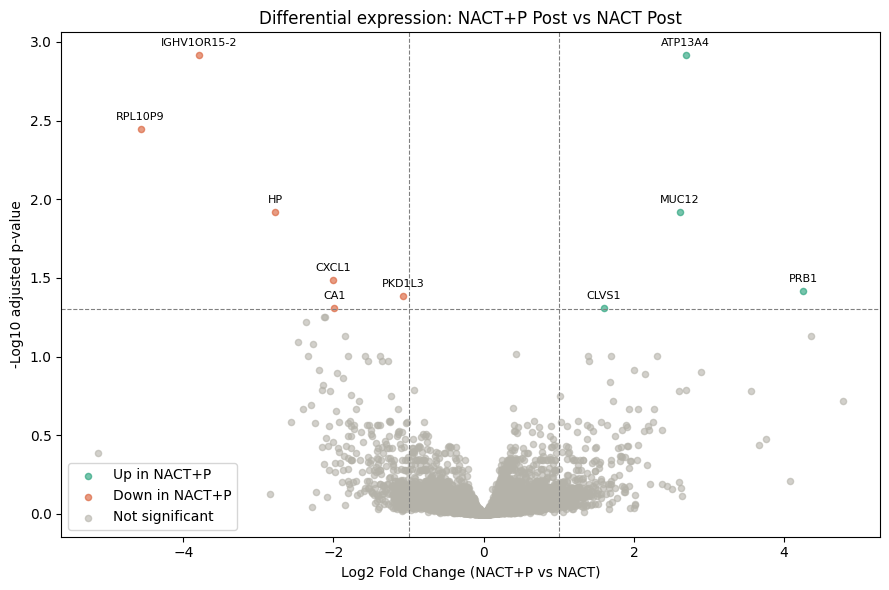

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare results for plotting
plot_df = results.copy().dropna()
plot_df['neg_log10_padj'] = -np.log10(plot_df['padj'])

# Define significance categories
def categorize(row):
    if row['padj'] < 0.05 and row['log2FoldChange'] > 1:
        return 'Up in NACT+P'
    elif row['padj'] < 0.05 and row['log2FoldChange'] < -1:
        return 'Down in NACT+P'
    else:
        return 'Not significant'

plot_df['category'] = plot_df.apply(categorize, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    'Up in NACT+P': '#1D9E75',
    'Down in NACT+P': '#D85A30',
    'Not significant': '#B4B2A9'
}

for cat, color in colors.items():
    mask = plot_df['category'] == cat
    ax.scatter(plot_df[mask]['log2FoldChange'],
               plot_df[mask]['neg_log10_padj'],
               color=color, alpha=0.6, s=20, label=cat)

# Label top 10 significant genes
top_genes = plot_df[plot_df['padj'] < 0.05].nsmallest(10, 'padj')
for gene, row in top_genes.iterrows():
    ax.annotate(gene,
                xy=(row['log2FoldChange'], row['neg_log10_padj']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

# Threshold lines
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8)
ax.axvline(1, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(-1, color='gray', linestyle='--', linewidth=0.8)

ax.set_xlabel('Log2 Fold Change (NACT+P vs NACT)')
ax.set_ylabel('-Log10 adjusted p-value')
ax.set_title('Differential expression: NACT+P Post vs NACT Post')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GSE227666/volcano_plot.png', dpi=300)
plt.show()

In [17]:
!pip install gseapy
import gseapy as gp

# Build ranked gene list - signed by direction
results_clean = results.dropna()
results_clean['rank_score'] = (
    np.sign(results_clean['log2FoldChange']) *
    -np.log10(results_clean['pvalue'])
)

ranked = results_clean['rank_score'].sort_values(ascending=False)

print(f"Ranked gene list length: {len(ranked)}")
print(f"Top 5 upregulated:\n{ranked.head()}")
print(f"\nTop 5 downregulated:\n{ranked.tail()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 11.1 MB/s eta 0:00:00
Ranked gene list length: 19116
Top 5 upregulated:
symbol
ATP13A4    7.150331
MUC12      5.573008
PRB1       4.852087
CLVS1      4.621712
MAGEA4     4.232913
Name: rank_score, dtype: float64

Top 5 downregulated:
symbol
PKD1L3        -4.762701
CXCL1         -4.992571
HP            -5.503925
RPL10P9       -6.252658
IGHV1OR15-2   -6.895716
Name: rank_score, dtype: float64


In [18]:
# Run GSEA using Hallmark gene sets
gsea_results = gp.prerank(
    rnk=ranked,
    gene_sets='MSigDB_Hallmark_2020',
    seed=42,
    permutation_num=1000,
    outdir=None,
    verbose=False
)

# Get results table
gsea_df = gsea_results.res2d
print(gsea_df.shape)
print(gsea_df[['Term', 'NES', 'NOM p-val', 'FDR q-val']].sort_values('FDR q-val').head(20))

(50, 10)
                                 Term       NES  NOM p-val  FDR q-val
0   Epithelial Mesenchymal Transition -2.493958   0.001000   0.001000
1               Inflammatory Response -2.406942   0.001000   0.001000
2            IL-6/JAK/STAT3 Signaling -2.153749   0.001000   0.001000
3       TNF-alpha Signaling via NF-kB -2.069991   0.001000   0.001000
4                   KRAS Signaling Up -1.909268   0.001000   0.001000
6                      UV Response Dn -1.785581   0.001000   0.001076
5                          Myogenesis -1.792414   0.001000   0.001256
10          Interferon Gamma Response -1.604466   0.001000   0.007722
9                          Complement -1.612144   0.001000   0.008161
11                    Apical Junction -1.591307   0.001000   0.008218
8                        Angiogenesis -1.624991   0.004630   0.008240
12                       Adipogenesis -1.561989   0.001000   0.010358
7                          DNA Repair   1.69534   0.001000   0.013633
13         

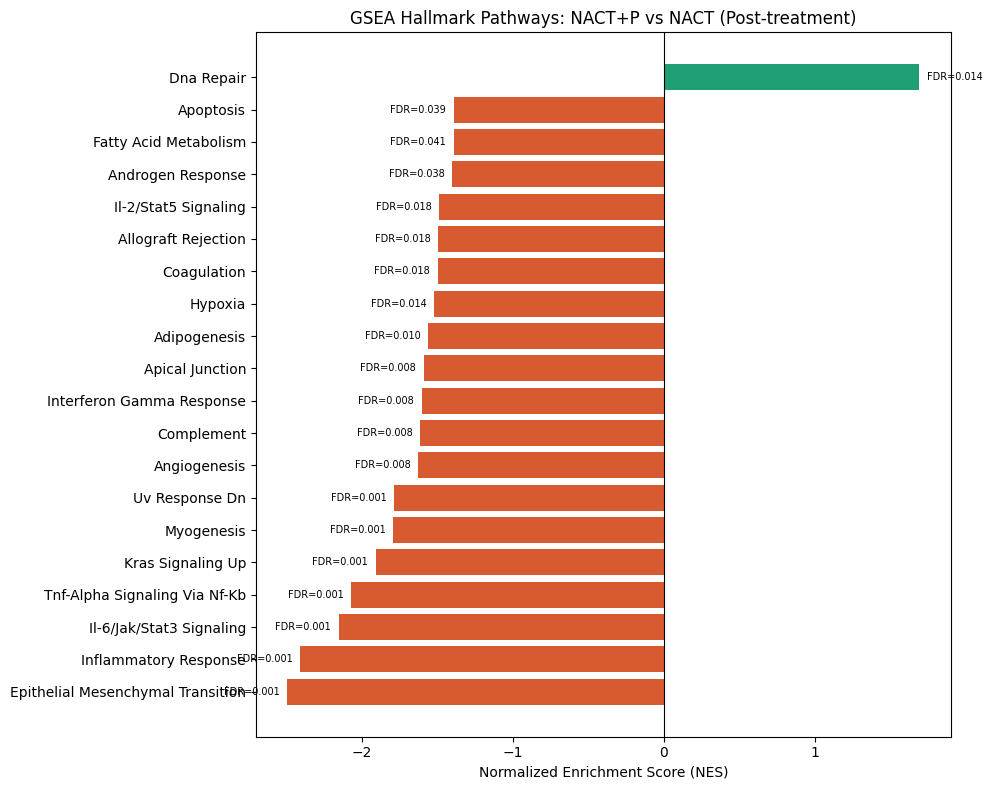

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Filter significant pathways
sig_gsea = gsea_df[gsea_df['FDR q-val'] < 0.05].copy()
sig_gsea = sig_gsea.sort_values('NES')

# Clean term names
sig_gsea['Term'] = sig_gsea['Term'].str.replace('_', ' ').str.title()

# Colors by direction
colors = ['#D85A30' if x < 0 else '#1D9E75' for x in sig_gsea['NES']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(sig_gsea['Term'], sig_gsea['NES'], color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Normalized Enrichment Score (NES)')
ax.set_title('GSEA Hallmark Pathways: NACT+P vs NACT (Post-treatment)')

# Add FDR labels
for i, (nes, fdr) in enumerate(zip(sig_gsea['NES'], sig_gsea['FDR q-val'])):
    x = nes + (0.05 if nes > 0 else -0.05)
    ha = 'left' if nes > 0 else 'right'
    ax.text(x, i, f'FDR={fdr:.3f}', va='center', ha=ha, fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GSE227666/GSEA_hallmark.png', dpi=300)
plt.show()

In [20]:
print(results.shape)
print(sig.shape)
print(ranked.head())

(19116, 6)
(10, 6)
symbol
ATP13A4    7.150331
MUC12      5.573008
PRB1       4.852087
CLVS1      4.621712
MAGEA4     4.232913
Name: rank_score, dtype: float64


In [21]:
# Separate up and down genes
up_genes = sig[sig['log2FoldChange'] > 0].index.tolist()
down_genes = sig[sig['log2FoldChange'] < 0].index.tolist()

print(f"Upregulated genes: {up_genes}")
print(f"Downregulated genes: {down_genes}")

# Run ORA on downregulated genes (the immune story)
ora_down = gp.enrichr(
    gene_list=down_genes,
    gene_sets=['GO_Biological_Process_2021', 'KEGG_2021_Human'],
    outdir=None,
    verbose=False
)

# Run ORA on upregulated genes
ora_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets=['GO_Biological_Process_2021', 'KEGG_2021_Human'],
    outdir=None,
    verbose=False
)

# Show top results
print("\nTop downregulated pathways:")
print(ora_down.results[['Gene_set', 'Term', 'Adjusted P-value', 'Genes']].sort_values('Adjusted P-value').head(10))

print("\nTop upregulated pathways:")
print(ora_up.results[['Gene_set', 'Term', 'Adjusted P-value', 'Genes']].sort_values('Adjusted P-value').head(10))

Upregulated genes: ['ATP13A4', 'CLVS1', 'MUC12', 'PRB1']
Downregulated genes: ['CA1', 'CXCL1', 'HP', 'IGHV1OR15-2', 'PKD1L3', 'RPL10P9']

Top downregulated pathways:
                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   
5  GO_Biological_Process_2021   
6  GO_Biological_Process_2021   
7  GO_Biological_Process_2021   
8  GO_Biological_Process_2021   
9  GO_Biological_Process_2021   

                                                Term  Adjusted P-value  \
0      sensory perception of sour taste (GO:0050915)          0.026702   
1  negative regulation of hydrogen peroxide metab...          0.026702   
2                 inflammatory response (GO:0006954)          0.026702   
3        cellular response to acidic pH (GO:0071468)          0.026702   
4           sensory perception of taste (GO:0050909)          0.026702   
5  negative regulation of 

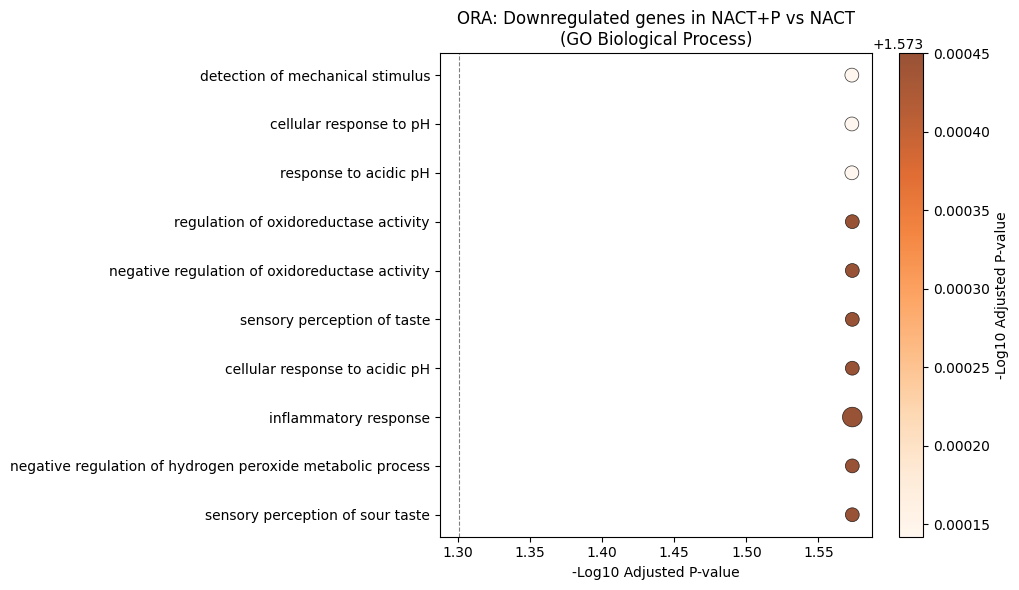

Key finding: inflammatory response independently confirmed by ORA


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Filter significant ORA results
ora_down_sig = ora_down.results[
    ora_down.results['Adjusted P-value'] < 0.05
].copy()

# Keep only GO terms (more biologically meaningful here)
ora_down_sig = ora_down_sig[
    ora_down_sig['Gene_set'] == 'GO_Biological_Process_2021'
].head(10)

# Clean term names - remove GO ID
ora_down_sig['Term_clean'] = ora_down_sig['Term'].str.replace(
    r'\s*\(GO:\d+\)', '', regex=True
).str.strip()

# Calculate gene ratio
ora_down_sig['Gene_ratio'] = ora_down_sig['Genes'].str.split(';').apply(len)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    -np.log10(ora_down_sig['Adjusted P-value']),
    ora_down_sig['Term_clean'],
    s=ora_down_sig['Gene_ratio'] * 100,
    c=-np.log10(ora_down_sig['Adjusted P-value']),
    cmap='Oranges',
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5
)

plt.colorbar(scatter, ax=ax, label='-Log10 Adjusted P-value')
ax.set_xlabel('-Log10 Adjusted P-value')
ax.set_title('ORA: Downregulated genes in NACT+P vs NACT\n(GO Biological Process)')
ax.axvline(-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GSE227666/ORA_downregulated.png', dpi=300)
plt.show()

print("Key finding: inflammatory response independently confirmed by ORA")

In [23]:
# Get leading edge genes from top immune pathways in GSEA
gsea_df = gsea_results.res2d

# Pull leading edge genes from Inflammatory Response pathway
inflam = gsea_df[gsea_df['Term'] == 'Inflammatory Response'].iloc[0]
leading_edge_genes = inflam['Lead_genes'].split(';')

print(f"Leading edge genes in Inflammatory Response: {len(leading_edge_genes)}")
print(leading_edge_genes[:20])

Leading edge genes in Inflammatory Response: 78
['IL1B', 'IL6', 'SELE', 'CXCL6', 'IL1A', 'TNFAIP6', 'CCL2', 'APLNR', 'ICAM1', 'RGS16', 'TACR1', 'CALCRL', 'OSMR', 'CCL7', 'GP1BA', 'CCR7', 'ADGRE1', 'MET', 'PROK2', 'CCL20']


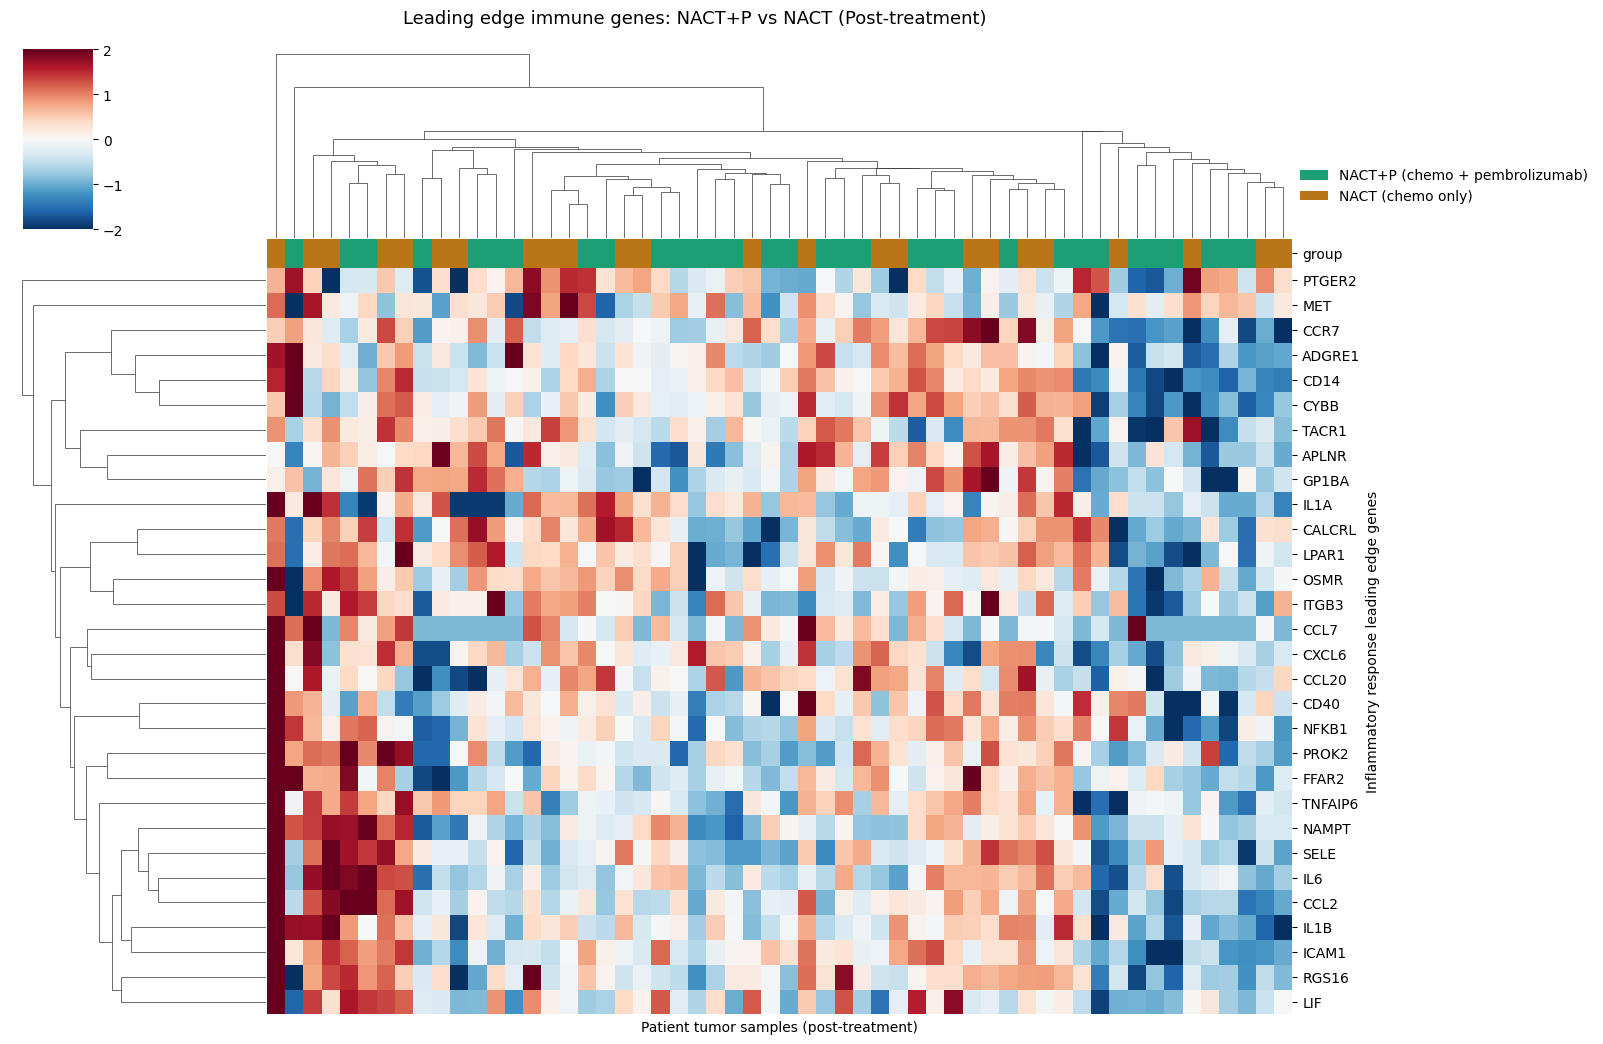

In [24]:
import seaborn as sns

# Use top 30 leading edge genes for visual clarity
top_genes = leading_edge_genes[:30]

# Subset count matrix to post samples and these genes
post_sample_ids = post_samples.index.tolist()
heatmap_data = df_filtered.loc[top_genes, post_sample_ids]

# Log normalize
heatmap_log = np.log2(heatmap_data + 1)

# Z-score each gene across samples
heatmap_z = heatmap_log.subtract(heatmap_log.mean(axis=1), axis=0)
heatmap_z = heatmap_z.divide(heatmap_log.std(axis=1), axis=0)

# Build column color bar by treatment group
group_colors = post_samples['group'].map({
    'NACTP': '#1D9E75',
    'NACT': '#BA7517'
})

# Plot
fig = sns.clustermap(
    heatmap_z,
    col_colors=group_colors,
    cmap='RdBu_r',
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0,
    col_cluster=True,
    row_cluster=True
)

fig.ax_heatmap.set_xlabel('Patient tumor samples (post-treatment)')
fig.ax_heatmap.set_ylabel('Inflammatory response leading edge genes')
fig.fig.suptitle(
    'Leading edge immune genes: NACT+P vs NACT (Post-treatment)',
    y=1.02, fontsize=13
)

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1D9E75', label='NACT+P (chemo + pembrolizumab)'),
    Patch(facecolor='#BA7517', label='NACT (chemo only)')
]
fig.ax_heatmap.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(1.3, 1.15),
    frameon=False,
    fontsize=10
)

plt.savefig('/content/drive/MyDrive/GSE227666/heatmap_immune_genes.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Print a summary of everything to document
print("=== ANALYSIS COMPLETE ===")
print(f"Dataset: GSE227666 — NeoPembrOV clinical trial")
print(f"Samples analyzed: 56 post-treatment (32 NACT+P, 24 NACT)")
print(f"Genes tested: {results.shape[0]}")
print(f"Significant DE genes: {sig.shape[0]}")
print(f"GSEA significant pathways (FDR<0.05): {(gsea_results.res2d['FDR q-val'] < 0.05).sum()}")
print(f"Key finding: Broad immune pathway suppression in pembrolizumab arm")
print(f"Top suppressed pathway NES: {gsea_results.res2d.sort_values('NES').iloc[0]['NES']:.3f}")
print(f"Top suppressed pathway: {gsea_results.res2d.sort_values('NES').iloc[0]['Term']}")

=== ANALYSIS COMPLETE ===
Dataset: GSE227666 — NeoPembrOV clinical trial
Samples analyzed: 56 post-treatment (32 NACT+P, 24 NACT)
Genes tested: 19116
Significant DE genes: 10
GSEA significant pathways (FDR<0.05): 20
Key finding: Broad immune pathway suppression in pembrolizumab arm
Top suppressed pathway NES: -2.494
Top suppressed pathway: Epithelial Mesenchymal Transition
